# 🏆 EDA — FIFA World Cup History (1930–2022)
**World Cup 2026 Predictor** · Exploratory analysis of the historical data that will feed the prediction model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1. Data loading
We load the 5 main tables: historical matches, goals, tournaments, 2026 squads and the 2026 fixture.

In [2]:
# Relative paths: the notebook lives in notebooks/, the data in ../data/
PATH = "../data/raw"

matches     = pd.read_csv(PATH + "/historical/matches.csv")
goals       = pd.read_csv(PATH + "/historical/goals.csv")
tournaments = pd.read_csv(PATH + "/historical/tournaments.csv")
squads26    = pd.read_csv(PATH + "/squads_2026/squads_2026.csv")
fixture     = pd.read_csv(PATH + "/fixture_2026/fixture_2026.csv")

## 2. First look
Dimensions, columns, data types and missing values of each table.

In [3]:
for name, df in [("matches", matches), ("goals", goals), ("squads26", squads26), ("fixture", fixture)]:
    print(f"\n{'='*55}")
    print(f"📋 {name} — {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"{'='*55}")
    print(list(df.columns))


📋 matches — 1248 rows x 37 columns
['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name', 'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed', 'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name', 'city_name', 'country_name', 'home_team_id', 'home_team_name', 'home_team_code', 'away_team_id', 'away_team_name', 'away_team_code', 'score', 'home_team_score', 'away_team_score', 'home_team_score_margin', 'away_team_score_margin', 'extra_time', 'penalty_shootout', 'score_penalties', 'home_team_score_penalties', 'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win', 'draw']

📋 goals — 3637 rows x 27 columns
['key_id', 'goal_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name', 'match_date', 'stage_name', 'group_name', 'team_id', 'team_name', 'team_code', 'home_team', 'away_team', 'player_id', 'family_name', 'given_name', 'shirt_number', 'player_team_id', 'player_team_name', 'player_team_code', 'minute_label', 

## 3. Data quality & cleaning
Before any analysis we validate the data: structure, completeness and cross-source consistency.

### Step 1 — Structure, nulls and duplicates

In [4]:
for name, df in [("matches", matches), ("goals", goals), ("squads26", squads26), ("fixture", fixture)]:
    print(f"\n{'='*55}")
    print(f"📋 {name}: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"   Duplicates: {df.duplicated().sum()}")
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print("   Columns with nulls:")
        print(nulls.to_string())
    else:
        print("   No nulls ✅")


📋 matches: 1248 rows x 37 columns
   Duplicates: 0
   No nulls ✅

📋 goals: 3637 rows x 27 columns
   Duplicates: 0
   No nulls ✅

📋 squads26: 1246 rows x 11 columns
   Duplicates: 0
   No nulls ✅

📋 fixture: 104 rows x 9 columns
   Duplicates: 0
   Columns with nulls:
group      32
score1    104
score2    104


**How to read the nulls:** some are legitimate, not errors — `group_name` is empty for knockout matches
(they have no group), and `score1/score2` are empty in the fixture because those matches have not been
played yet. The job here is to tell *legitimate null* from *problem null*.

### Step 2 — Are all tournaments, teams and players there?

In [5]:
# How many tournaments? (30 including women's; 22 men's World Cups: 1930-2022)
print("Tournaments:", matches["tournament_name"].nunique())

# Matches per tournament (early editions had fewer; since 1998 it must be 64)
print(matches.groupby(matches["tournament_name"].str[:4])["match_id"].nunique().to_string())

Tournaments: 30
tournament_name
1930    18
1934    17
1938    18
1950    22
1954    26
1958    35
1962    32
1966    32
1970    32
1974    38
1978    38
1982    52
1986    52
1990    52
1991    26
1994    52
1995    26
1998    64
1999    32
2002    64
2003    32
2006    64
2007    32
2010    64
2011    32
2014    64
2015    52
2018    64
2019    52
2022    64


In [6]:
matches.head()

,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,replay,match_date,match_time,stadium_id,stadium_name,city_name,country_name,home_team_id,home_team_name,home_team_code,away_team_id,away_team_name,away_team_code,score,home_team_score,away_team_score,home_team_score_margin,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,0,1930-07-13,15:00,S-240,Estadio Pocitos,Montevideo,Uruguay,T-30,France,FRA,T-46,Mexico,MEX,4–1,4,1,3,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,0,1930-07-13,15:00,S-239,Estadio Gran Parque Central,Montevideo,Uruguay,T-83,United States,USA,T-06,Belgium,BEL,3–0,3,0,3,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,0,1930-07-14,12:45,S-239,Estadio Gran Parque Central,Montevideo,Uruguay,T-87,Yugoslavia,YUG,T-09,Brazil,BRA,2–1,2,1,1,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,0,1930-07-14,14:50,S-240,Estadio Pocitos,Montevideo,Uruguay,T-61,Romania,ROU,T-56,Peru,PER,3–1,3,1,2,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,0,1930-07-15,16:00,S-239,Estadio Gran Parque Central,Montevideo,Uruguay,T-03,Argentina,ARG,T-30,France,FRA,1–0,1,0,1,-1,0,0,0-0,0,0,home team win,1,0,0


In [7]:
matches["tournament_name"].unique()

<StringArray>
[  '1930 FIFA Men's World Cup',   '1934 FIFA Men's World Cup',
   '1938 FIFA Men's World Cup',   '1950 FIFA Men's World Cup',
   '1954 FIFA Men's World Cup',   '1958 FIFA Men's World Cup',
   '1962 FIFA Men's World Cup',   '1966 FIFA Men's World Cup',
   '1970 FIFA Men's World Cup',   '1974 FIFA Men's World Cup',
   '1978 FIFA Men's World Cup',   '1982 FIFA Men's World Cup',
   '1986 FIFA Men's World Cup',   '1990 FIFA Men's World Cup',
 '1991 FIFA Women's World Cup',   '1994 FIFA Men's World Cup',
 '1995 FIFA Women's World Cup',   '1998 FIFA Men's World Cup',
 '1999 FIFA Women's World Cup',   '2002 FIFA Men's World Cup',
 '2003 FIFA Women's World Cup',   '2006 FIFA Men's World Cup',
 '2007 FIFA Women's World Cup',   '2010 FIFA Men's World Cup',
 '2011 FIFA Women's World Cup',   '2014 FIFA Men's World Cup',
 '2015 FIFA Women's World Cup',   '2018 FIFA Men's World Cup',
 '2019 FIFA Women's World Cup',   '2022 FIFA Men's World Cup']
Length: 30, dtype: str

### Filtering men's World Cups only
The dataset mixes men's and women's tournaments. Our target is the men's 2026 World Cup,
so we keep only men's editions — same population we want to predict.

In [8]:
matches_m = matches[matches["tournament_name"].str.contains("Men's")].copy()
tournaments_m = tournaments[tournaments["tournament_name"].str.contains("Men's")].copy()

print("Before:", matches["tournament_name"].nunique(), "tournaments,", len(matches), "matches")
print("After:", matches_m["tournament_name"].nunique(), "tournaments,", len(matches_m), "matches")

Before: 30 tournaments, 1248 matches
After: 22 tournaments, 964 matches


In [9]:
# squads26: are all 48 teams there? does the player count per team add up?
print("Teams in squads26:", squads26["team"].nunique())
print("\nPlayers per team (lowest counts):")
print(squads26.groupby("team").size().sort_values().head(5))

# fixture: are the 48 teams and 104 matches there?
fixture_teams = set(fixture["team1"]) | set(fixture["team2"])
print("\nTeams in fixture:", len(fixture_teams))
print("Matches in fixture:", len(fixture))

Teams in squads26: 48

Players per team (lowest counts):
team
Argentina    25
Austria      25
Algeria      26
Australia    26
Belgium      26
dtype: int64

Teams in fixture: 112
Matches in fixture: 104


**Observation:** 46 of the 48 teams registered the maximum of 26 players. Argentina and Austria
registered 25 (FIFA allows 23–26; verified against the source). Total: **1,246 players**.

### Step 3 — The key cross-check: do team names match across sources?
`squads26` comes from Wikipedia and `fixture` from openfootball. If the same country is spelled
differently in each source, joins would silently drop teams.

In [10]:
squad_teams = set(squads26["team"].unique())
fixture_teams = set(fixture["team1"]) | set(fixture["team2"])

print("In squads but NOT in fixture:", squad_teams - fixture_teams)
print("In fixture but NOT in squads:", fixture_teams - squad_teams)

In squads but NOT in fixture: {'Bosnia and Herzegovina', 'United States'}
In fixture but NOT in squads: {'2J', 'Bosnia & Herzegovina', 'W88', 'W99', 'W85', '3A/B/C/D/F', '2L', 'W76', '2D', '2A', 'L102', 'USA', 'W86', 'W82', '1F', 'W100', 'W94', '3E/F/G/I/J', '1C', 'W91', '1B', 'W83', '2E', 'W102', 'W97', '2C', '3C/D/F/G/H', '3B/E/F/I/J', 'W92', '1L', '2F', 'W75', 'W79', 'W95', 'W87', '2K', 'W73', 'W96', '1I', '3A/E/H/I/J', '1J', '3E/H/I/J/K', '2H', 'W78', 'W77', '2B', '1D', '3C/E/F/H/I', '1E', '1K', '2I', 'L101', '1A', 'W89', 'W93', 'W81', 'W84', '1G', 'W80', 'W101', 'W74', '1H', '3D/E/I/J/L', 'W90', '2G', 'W98'}


Two different things show up:
- **Knockout placeholders** (`1A`, `2B`, `W74`, `3A/B/C/D/F`, `L101`...) — matches whose teams are not
  decided yet (group winners, runners-up, best third-placed teams, match winners/losers). Not errors.
- **Real naming mismatches**: `USA` vs `United States` and `Bosnia & Herzegovina` vs
  `Bosnia and Herzegovina`. These we fix.

In [11]:
# Standardize the fixture to the squads/Wikipedia naming
name_map = {
    "USA": "United States",
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
}

fixture["team1"] = fixture["team1"].replace(name_map)
fixture["team2"] = fixture["team2"].replace(name_map)

# Re-check (group matches only, where real teams are known)
groups_2026 = fixture[fixture["group"].notna()]
fixture_teams = set(groups_2026["team1"]) | set(groups_2026["team2"])
squad_teams = set(squads26["team"].unique())

print("Differences:", squad_teams ^ fixture_teams)  # ^ = symmetric difference

Differences: set()


### Validation summary
- ✅ 30 tournaments in the historical data → filtered to 22 men's World Cups (1930-2022)
- ✅ 48 teams and 1,246 players in the 2026 squads (Argentina and Austria carry 25, verified)
- ✅ 104 matches in the 2026 fixture (72 group matches with confirmed teams + 32 knockout placeholders)
- ✅ Country names standardized across sources (USA → United States, Bosnia & Herzegovina → Bosnia and Herzegovina)

## 4. Univariate analysis

In [12]:
matches_m["year"] = matches_m["tournament_name"].str[:4].astype(int)
matches_m["total_goals"] = matches_m["home_team_score"] + matches_m["away_team_score"]

### 📊 4.1 — Goal scoring over time
Are more or fewer goals scored than in the past?

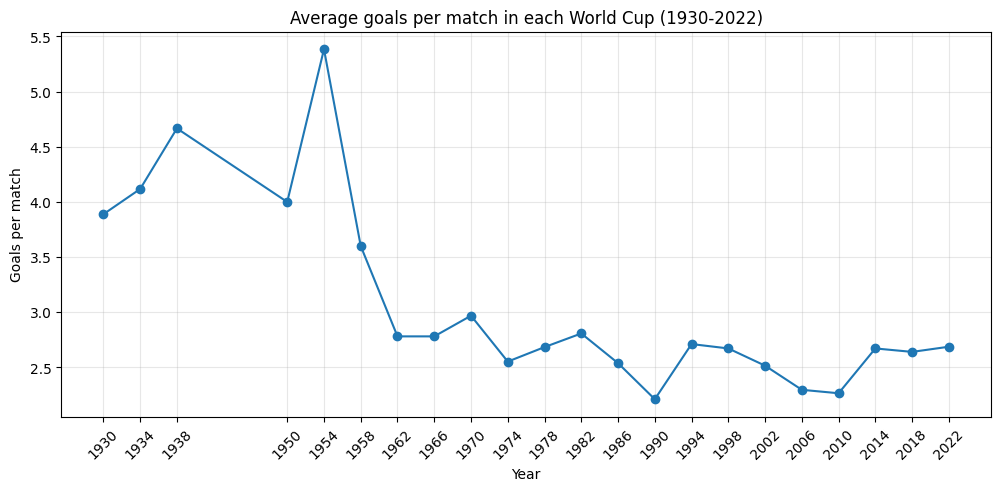

In [13]:
goals_per_year = matches_m.groupby("year")["total_goals"].mean()

plt.figure(figsize=(12, 5))
plt.plot(goals_per_year.index, goals_per_year.values, marker="o")
plt.title("Average goals per match in each World Cup (1930-2022)")
plt.xlabel("Year")
plt.ylabel("Goals per match")
plt.xticks(goals_per_year.index, rotation=45)  # one tick per World Cup
plt.grid(alpha=0.3)
plt.show()

**Interpretation:**
- Pre-1960 football averaged 4–5 goals per match, peaking at Switzerland 1954 (5.4 — all-time record).
- From 1962 onwards there is a structural break: the average stabilizes between 2.2 and 3.0 goals,
  matching the rise of tactical, defensive football.
- All-time low at Italia 1990 (2.2), which triggered FIFA rule changes (back-pass rule, 3 points per win).
- Note the 1942/1946 gap: tournaments cancelled due to World War II.

### 📊 4.2 — Most successful teams
West Germany and Germany are the same FIFA federation, so we merge them before counting titles.

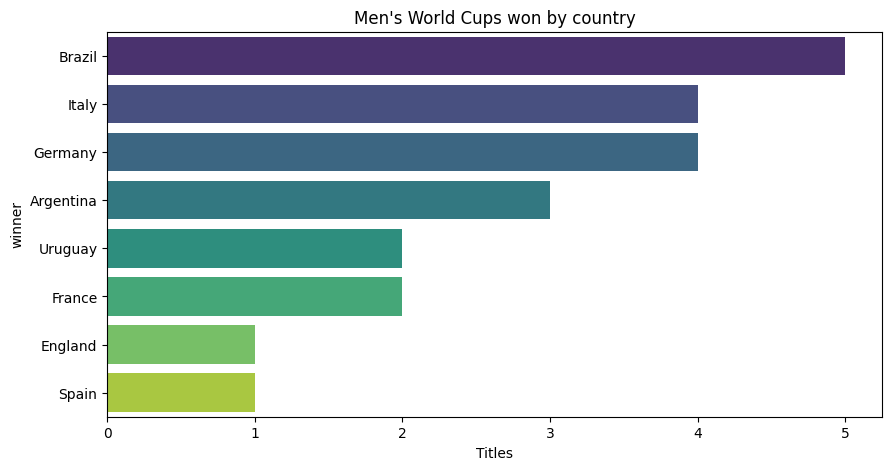

In [14]:
tournaments_m["winner"] = tournaments_m["winner"].replace({"West Germany": "Germany"})
champions = tournaments_m["winner"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=champions.values, y=champions.index, hue=champions.index, palette="viridis", legend=False)
plt.title("Men's World Cups won by country")
plt.xlabel("Titles")
plt.show()

### Defunct national teams
The historical data contains teams that no longer exist. For team-level historical features they will
be mapped to their official FIFA heirs (done at the feature engineering stage, not here — the EDA
should reflect history as it happened).

In [15]:
# Historical teams that are not in the 2026 squads (defunct nations + teams that did not qualify)
historical_teams = set(matches_m["home_team_name"]) | set(matches_m["away_team_name"])
teams_2026 = set(squads26["team"].unique())
print(sorted(historical_teams - teams_2026))

['Angola', 'Bolivia', 'Bulgaria', 'Cameroon', 'Chile', 'China', 'Costa Rica', 'Cuba', 'Czechoslovakia', 'Denmark', 'Dutch East Indies', 'East Germany', 'El Salvador', 'Greece', 'Honduras', 'Hungary', 'Iceland', 'Israel', 'Italy', 'Jamaica', 'Kuwait', 'Nigeria', 'North Korea', 'Northern Ireland', 'Peru', 'Poland', 'Republic of Ireland', 'Romania', 'Russia', 'Serbia', 'Serbia and Montenegro', 'Slovakia', 'Slovenia', 'Soviet Union', 'Togo', 'Trinidad and Tobago', 'Ukraine', 'United Arab Emirates', 'Wales', 'West Germany', 'Yugoslavia', 'Zaire']


In [16]:
# Mapping of defunct national teams to their official FIFA heirs (applied at feature engineering)
HEIR_NATIONS = {
    "West Germany": "Germany",
    "Soviet Union": "Russia",
    "Yugoslavia": "Serbia",
    "Serbia and Montenegro": "Serbia",
    "Czechoslovakia": "Czech Republic",
    "Zaire": "DR Congo",
    "Dutch East Indies": "Indonesia",
    # East Germany is excluded: no FIFA heir, only 1 World Cup (1974)
}

### 📊 4.3 — Result distribution (the key number for our model)

home_team_win    51.3
draw             24.4
away_team_win    24.4
dtype: float64


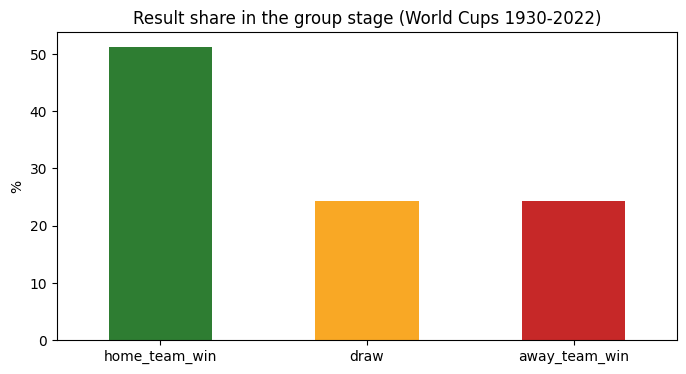

In [17]:
group_matches = matches_m[matches_m["group_stage"] == 1]

results = group_matches[["home_team_win", "draw", "away_team_win"]].mean() * 100
print(results.round(1))

results.plot(kind="bar", figsize=(8, 4), color=["#2E7D32", "#F9A825", "#C62828"])
plt.title("Result share in the group stage (World Cups 1930-2022)")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.show()

**Key interpretation for the model:**
- Draws account for 24.4% of group-stage matches: a minority class and the hardest one to predict.
- The "home team" wins 51.3% despite playing on neutral ground → the home/away label partly reflects
  the draw seeding (seeded teams, hosts), not real home advantage. Caveat for feature design.
- **Project baseline:** always predicting "home team wins" scores ~51% accuracy.
  Our model must clearly beat that bar to add value.

### 🔍 Drill-down 1 — What happened at Switzerland 1954?

In [18]:
wc54 = matches_m[matches_m["year"] == 1954]

# Highest-scoring matches of that World Cup
wc54_top = wc54.sort_values("total_goals", ascending=False)
wc54_top[["match_name", "stage_name", "score", "total_goals"]].head(10)

,match_name,stage_name,score,total_goals
93,Austria vs Switzerland,quarter-finals,7–5,12
87,Hungary vs West Germany,group stage,8–3,11
80,Hungary vs South Korea,group stage,9–0,9
91,West Germany vs Turkey,group stage,7–2,9
82,England vs Belgium,group stage,4–4,8
83,Uruguay vs Scotland,group stage,7–0,7
88,Turkey vs South Korea,group stage,7–0,7
98,West Germany vs Austria,semi-finals,6–1,7
95,Hungary vs Brazil,quarter-finals,4–2,6
94,Uruguay vs England,quarter-finals,4–2,6


### 🔍 Drill-down 2 — Highest-scoring matches in World Cup history

In [19]:
matches_m.sort_values("total_goals", ascending=False)[
    ["year", "match_name", "stage_name", "score", "total_goals"]
].head(10)

,year,match_name,stage_name,score,total_goals
93,1954,Austria vs Switzerland,quarter-finals,7–5,12
312,1982,Hungary vs El Salvador,group stage,10–1,11
87,1954,Hungary vs West Germany,group stage,8–3,11
40,1938,Brazil vs Poland,round of 16,6–5,11
104,1958,France vs Paraguay,group stage,7–3,10
134,1958,France vs West Germany,third-place match,6–3,9
10,1930,Argentina vs Mexico,group stage,6–3,9
243,1974,Yugoslavia vs Zaire,group stage,9–0,9
91,1954,West Germany vs Turkey,group stage,7–2,9
80,1954,Hungary vs South Korea,group stage,9–0,9


### 🔍 Drill-down 3 — Why was Italia 90 so poor? More draws or fewer goals?

In [20]:
# Share of draws and of low-scoring matches (0 or 1 goal), per World Cup
yearly_stats = matches_m.groupby("year").agg(
    avg_goals=("total_goals", "mean"),
    pct_draws=("draw", "mean"),
    pct_low_scoring=("total_goals", lambda x: (x <= 1).mean()),
).round(3) * [1, 100, 100]

yearly_stats.loc[[1954, 1986, 1990, 1994, 2022]]  # key years compared

,avg_goals,pct_draws,pct_low_scoring
year,,,
1954,5.385,7.7,7.7
1986,2.538,21.2,26.9
1990,2.212,15.4,38.5
1994,2.712,15.4,25.0
2022,2.688,15.6,26.6


Italia 90 does **not** stand out for draws (15.4%, fewer than 1986) but for closed matches:
**38.5% of its matches ended with 0 or 1 goal** — a tournament of low-scoring grinds, not of draws.

### 🔍 Drill-down 4 — Quantifying the era break

In [21]:
matches_m["era"] = matches_m["year"].apply(lambda y: "1930-1958" if y <= 1958 else "1962-2022")

matches_m.groupby("era").agg(
    matches=("match_id", "count"),
    avg_goals=("total_goals", "mean"),
    pct_draws=("draw", "mean"),
).round(2)

,matches,avg_goals,pct_draws
era,,,
1930-1958,136,4.25,0.14
1962-2022,828,2.59,0.19


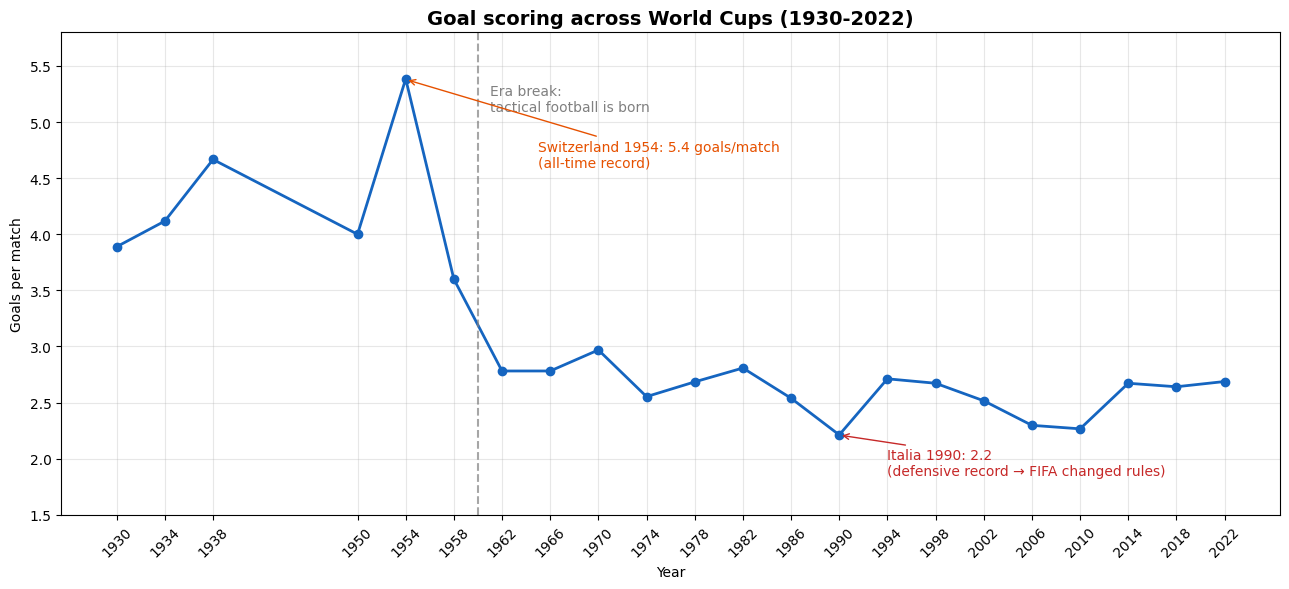

In [22]:
goals_per_year = matches_m.groupby("year")["total_goals"].mean()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(goals_per_year.index, goals_per_year.values, marker="o", color="#1565C0", linewidth=2)

# Vertical line marking the era break
ax.axvline(x=1960, color="gray", linestyle="--", alpha=0.7)
ax.text(1961, 5.1, "Era break:\ntactical football is born", fontsize=10, color="gray")

# Annotate the 1954 peak
ax.annotate("Switzerland 1954: 5.4 goals/match\n(all-time record)",
            xy=(1954, 5.38), xytext=(1965, 4.6),
            arrowprops=dict(arrowstyle="->", color="#E65100"),
            fontsize=10, color="#E65100")

# Annotate the 1990 low
ax.annotate("Italia 1990: 2.2\n(defensive record → FIFA changed rules)",
            xy=(1990, 2.21), xytext=(1994, 1.85),
            arrowprops=dict(arrowstyle="->", color="#C62828"),
            fontsize=10, color="#C62828")

ax.set_title("Goal scoring across World Cups (1930-2022)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Goals per match")
ax.set_xticks(goals_per_year.index)
ax.set_xticklabels(goals_per_year.index, rotation=45)
ax.set_ylim(1.5, 5.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

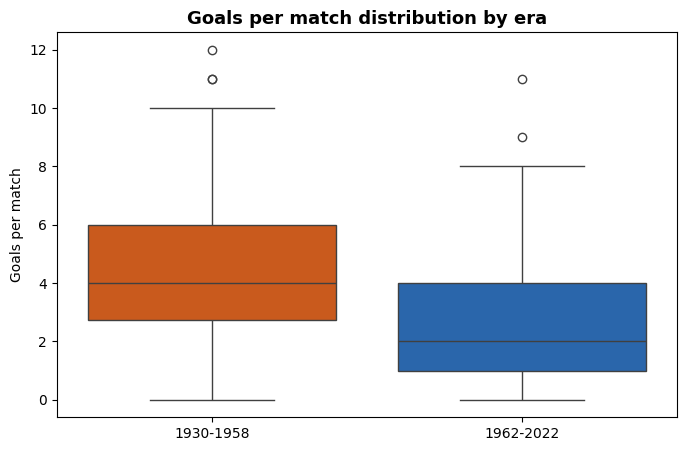

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=matches_m, x="era", y="total_goals", hue="era",
            palette=["#E65100", "#1565C0"], legend=False)
plt.title("Goals per match distribution by era", fontsize=13, fontweight="bold")
plt.xlabel("")
plt.ylabel("Goals per match")
plt.show()

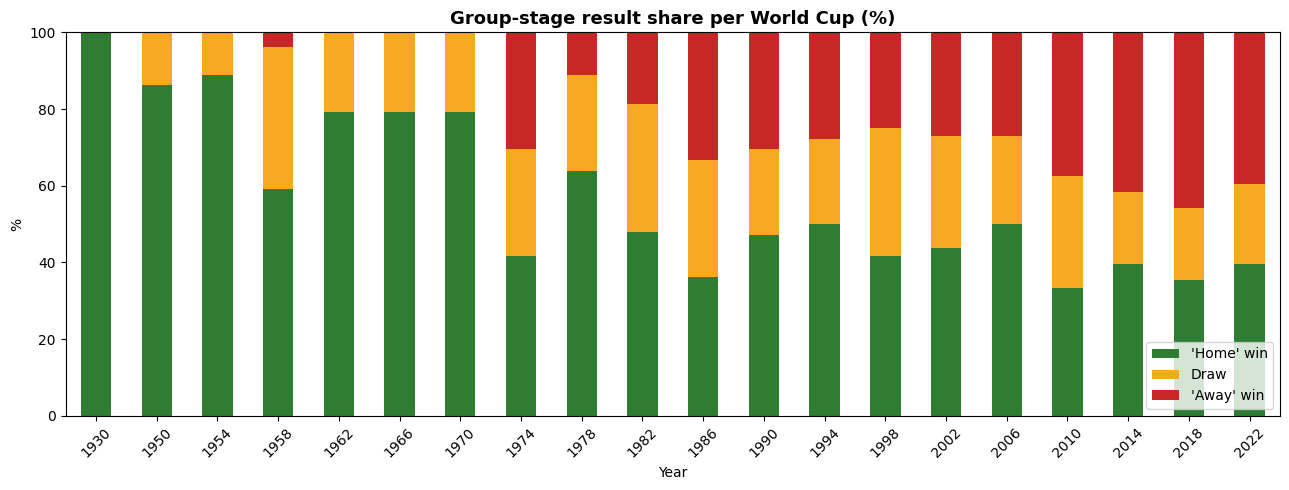

In [24]:
yearly_results = matches_m[matches_m["group_stage"] == 1].groupby("year")[
    ["home_team_win", "draw", "away_team_win"]
].mean() * 100

yearly_results.plot(kind="bar", stacked=True, figsize=(13, 5),
                    color=["#2E7D32", "#F9A825", "#C62828"])
plt.title("Group-stage result share per World Cup (%)", fontsize=13, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("%")
plt.legend(["'Home' win", "Draw", "'Away' win"], loc="lower right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Decision: training window for the model
The data shows a structural break around 1960:
- Goals per match: 4.25 (1930-1958) vs 2.59 (1962-2022) — a 39% drop
- Closed matches (≤1 goal) go from exception to norm (Italia 90: 38.5%)
- Draw share rises from 14% to 19% in the modern era

**Decision:** the model will be trained on World Cups from 1962 onwards. The early era is just
136 matches (14% of the data) of a statistically different game than the one we want to predict.

## 5. Bivariate analysis — hunting for model signals

### 📊 5.1 — Is there a host advantage?

In [25]:
# How many World Cups did the host win?
print("World Cups won by the host:", tournaments_m["host_won"].sum(), "of", len(tournaments_m))

# Host performance match by match
host_map = tournaments_m.set_index("tournament_name")["host_country"].to_dict()
matches_m["host_country"] = matches_m["tournament_name"].map(host_map)

matches_m["host_playing"] = (matches_m["home_team_name"] == matches_m["host_country"]) | \
                            (matches_m["away_team_name"] == matches_m["host_country"])

host_matches = matches_m[matches_m["host_playing"]]
host_wins = ((host_matches["home_team_name"] == host_matches["host_country"]) & (host_matches["home_team_win"] == 1)) | \
            ((host_matches["away_team_name"] == host_matches["host_country"]) & (host_matches["away_team_win"] == 1))

print(f"\nHost matches: {len(host_matches)}")
print(f"Host win rate: {host_wins.mean()*100:.1f}%")
print(f"Overall win rate (any team): {50 - matches_m['draw'].mean()*50:.1f}%")

World Cups won by the host: 6 of 22

Host matches: 110
Host win rate: 66.4%
Overall win rate (any team): 40.7%


**Interpretation — host advantage:**
- Hosts win 66.4% of their matches (vs 40.7% overall): a +26 point edge.
- 6 of 22 World Cups (27%) were won by the host.
- ✅ Feature confirmed: `is_host`
- ⚠️ 2026 nuance: for the first time there are 3 hosts (USA, Mexico, Canada). The advantage may be
  diluted (they only play part of their matches "at home") — the model will use the feature, but we
  flag it as a limitation to monitor.

### 📊 5.2 — Does scoring first win matches?

In [26]:
# Men's goals only; keep the first goal of each match
goals_m = goals[goals["tournament_name"].str.contains("Men's")].copy()
first_goal = goals_m.sort_values("minute_regulation").groupby("match_id").first().reset_index()
first_goal = first_goal[["match_id", "team_id"]].rename(columns={"team_id": "first_scorer_id"})

# Join with matches (matches with goals only)
df = matches_m.merge(first_goal, on="match_id", how="inner")

# Did the first-scoring team win?
df["first_scorer_won"] = ((df["first_scorer_id"] == df["home_team_id"]) & (df["home_team_win"] == 1)) | \
                         ((df["first_scorer_id"] == df["away_team_id"]) & (df["away_team_win"] == 1))

print(f"Matches with goals: {len(df)}")
print(f"First-scorer win rate: {df['first_scorer_won'].mean()*100:.1f}%")
print(f"Draw rate after scoring first: {df['draw'].mean()*100:.1f}%")

Matches with goals: 886
First-scorer win rate: 72.8%
Draw rate after scoring first: 12.8%


**Interpretation — first goal:**
- In matches with goals, the first-scoring team wins 72.8% of the time (only 12.8% end in a draw).
- ⚠️ Not a pre-match feature (unknown before kick-off), but it validates a possible future
  extension: a live, in-match prediction model.

### 📊 5.3 — Are knockouts decided differently than the group stage?

In [27]:
matches_m.groupby("knockout_stage").agg(
    matches=("match_id", "count"),
    avg_goals=("total_goals", "mean"),
    pct_draws_90min=("draw", "mean"),
    pct_extra_time=("extra_time", "mean"),
).round(2)

,matches,avg_goals,pct_draws_90min,pct_extra_time
knockout_stage,,,,
0,718,2.69,0.24,0.00
1,246,3.20,0.02,0.28


**Interpretation — groups vs knockouts:**
- Knockouts: more goals (3.20 vs 2.69, inflated by the 28% of matches going to extra time) and no
  draws (the residual 2% are pre-1978 replays, before penalty shootouts existed).
- **Modeling decision:** the problem changes by stage →
  - Group stage: 3-class classification (home win / draw / away win)
  - Knockouts: 2 classes (team A advances / team B advances)

  Model v1 will focus on the group stage (72 of the 104 matches in 2026).

## 6. Conclusions

1. **Training window:** structural break around 1960 (4.25 → 2.59 goals/match, -39%).
   The model will be trained on World Cups from 1962 onwards (only 14% of the data is lost).
2. **Baseline to beat:** always predicting "home team wins" scores ~51% in the group stage.
   The draw (24.4%) will be the hardest class.
3. **Confirmed features:** `is_host` (hosts win 66.4% of their matches, +26 points over the mean).
   6 of 22 World Cups were won by the host.
4. **Caveats:** the home/away label hides the draw seeding (not real home advantage); defunct
   national teams will be mapped to their FIFA heirs (West Germany → Germany, Soviet Union → Russia,
   Yugoslavia → Serbia...).
5. **Narrative insight:** the first-scoring team wins 72.8% of matches with goals
   (only 12.8% end in a draw).
6. **Stage-dependent modeling:** group stage → 3 classes (1/X/2); knockouts → 2 classes
   (no draws since penalty shootouts were introduced in 1978). Model v1 focuses on the
   72 group-stage matches of 2026.

**Next step:** notebook 02 — feature engineering and model v0.